In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Налаштування стилю для красивих графіків
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# 1/ Завантаження даних
df = pd.read_csv('../Video_Games_Sales_as_at_22_Dec_2016.csv')
print(f"Початкова кількість рядків: {len(df)}")

# DATA CLEANING

# 1. Видаляємо рядки, де взагалі немає назви гри, року або жанру (їх небагато)
df.dropna(subset=['Name', 'Year_of_Release', 'Genre'], inplace=True)

# 2. Оцінка користувачів (User_Score) має тип object через текстове значення 'tbd' (to be determined)
# Замінюємо 'tbd' на NaN, а потім конвертуємо колонку у дробове число (float), оскільки будувати графіки та гістограми можна лише за числовими даними.
df['User_Score'] = df['User_Score'].replace('tbd', np.nan).astype(float)

# 3. Видаляємо ігри, де немає оцінок критиків (для наших графіків вони будуть ключовими)
df.dropna(subset=['Critic_Score'], inplace=True)

# 4. Перетворюємо рік випуску на ціле число (Integer)
df['Year_of_Release'] = df['Year_of_Release'].astype(int)

print(f"Кількість рядків після очищення (Data Cleaning): {len(df)}")
display(df.head())

Початкова кількість рядків: 16719
Кількість рядків після очищення (Data Cleaning): 7983


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
6,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0,Nintendo,E
7,Wii Play,Wii,2006,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0,Nintendo,E


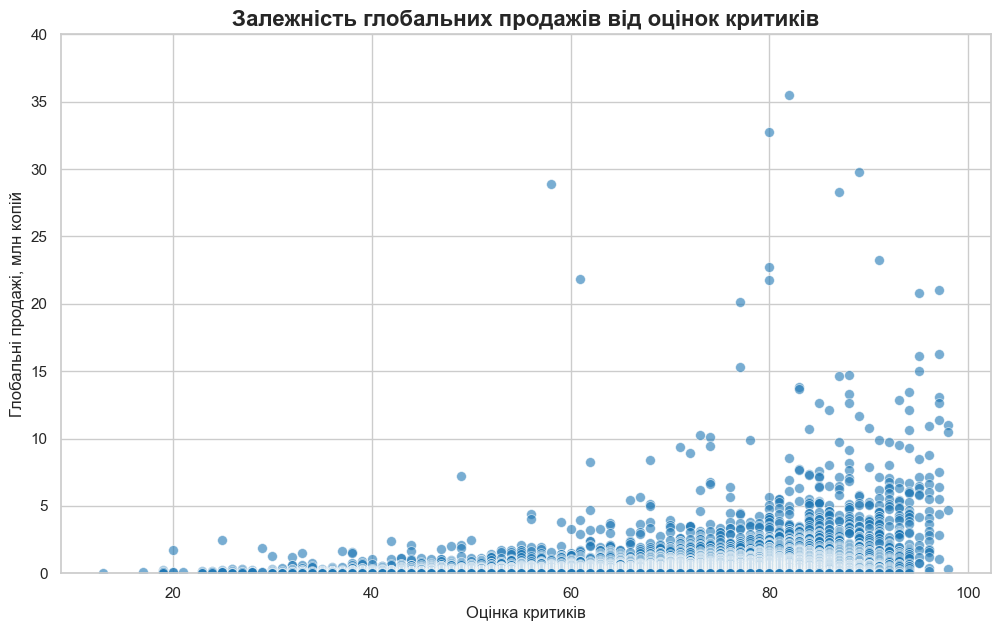

In [12]:
#  Графік 1: Залежність одного integer/real атрибута від іншого

plt.figure(figsize=(12, 7))

# Будуємо точковий графік: X - оцінка критиків, Y - глобальні продажі
sns.scatterplot(
    data=df,
    x='Critic_Score',
    y='Global_Sales',
    alpha=0.6,           # Напівпрозорість точок для кращої видимості скупчень
    color='#1f77b4',     # Приємний синій колір
    edgecolor='w',       # Біла обводка точок
    s=50                 # Розмір точок
)

plt.title('Залежність глобальних продажів від оцінок критиків', fontsize=16, fontweight='bold')
plt.xlabel('Оцінка критиків', fontsize=12)
plt.ylabel('Глобальні продажі, млн копій', fontsize=12)

# Обмежуємо вісь Y (до 40 млн), щоб аномальні викиди не стискали весь графік
plt.ylim(0, 40)

plt.show()

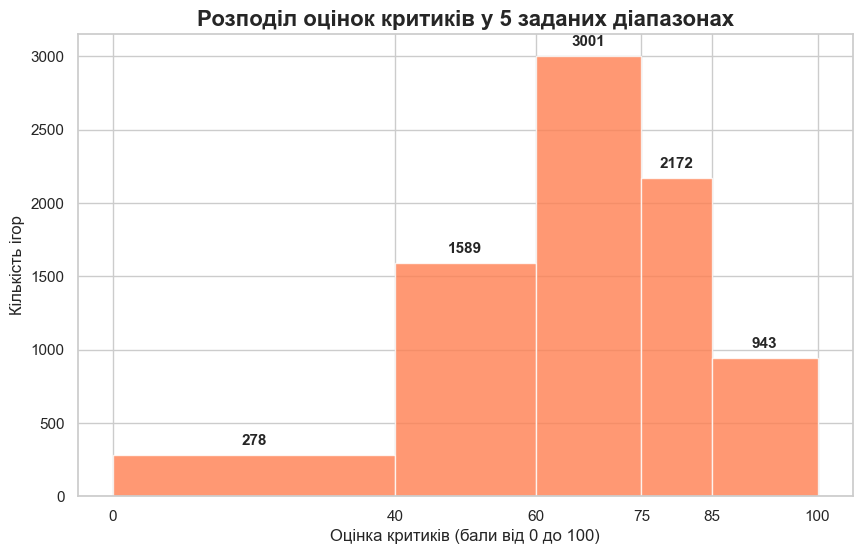

In [13]:
# Графік 2: Гістограма з 5 заданими діапазонами

plt.figure(figsize=(10, 6))

# Задаємо 5 конкретних діапазонів (bins) для гістограми
# 0-40 (погані), 40-60 (посередні), 60-75 (норм), 75-85 (хороші), 85-100 (хіти)
custom_bins = [0, 40, 60, 75, 85, 100]

# Будуємо гістограму
n, bins, patches = plt.hist(
    df['Critic_Score'],
    bins=custom_bins,
    color='coral',
    alpha=0.8
)

plt.title('Розподіл оцінок критиків у 5 заданих діапазонах', fontsize=16, fontweight='bold')
plt.xlabel('Оцінка критиків (бали від 0 до 100)', fontsize=12)
plt.ylabel('Кількість ігор', fontsize=12)

# Додаємо підписи кількості ігор над кожним стовпчиком для наочності
for i in range(len(patches)):
    plt.text(
        patches[i].get_x() + patches[i].get_width() / 2,
        patches[i].get_height() + 50,
        f'{int(n[i])}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

# Налаштовуємо мітки на осі X, щоб вони чітко співпадали з нашими межами
plt.xticks(custom_bins)

plt.show()

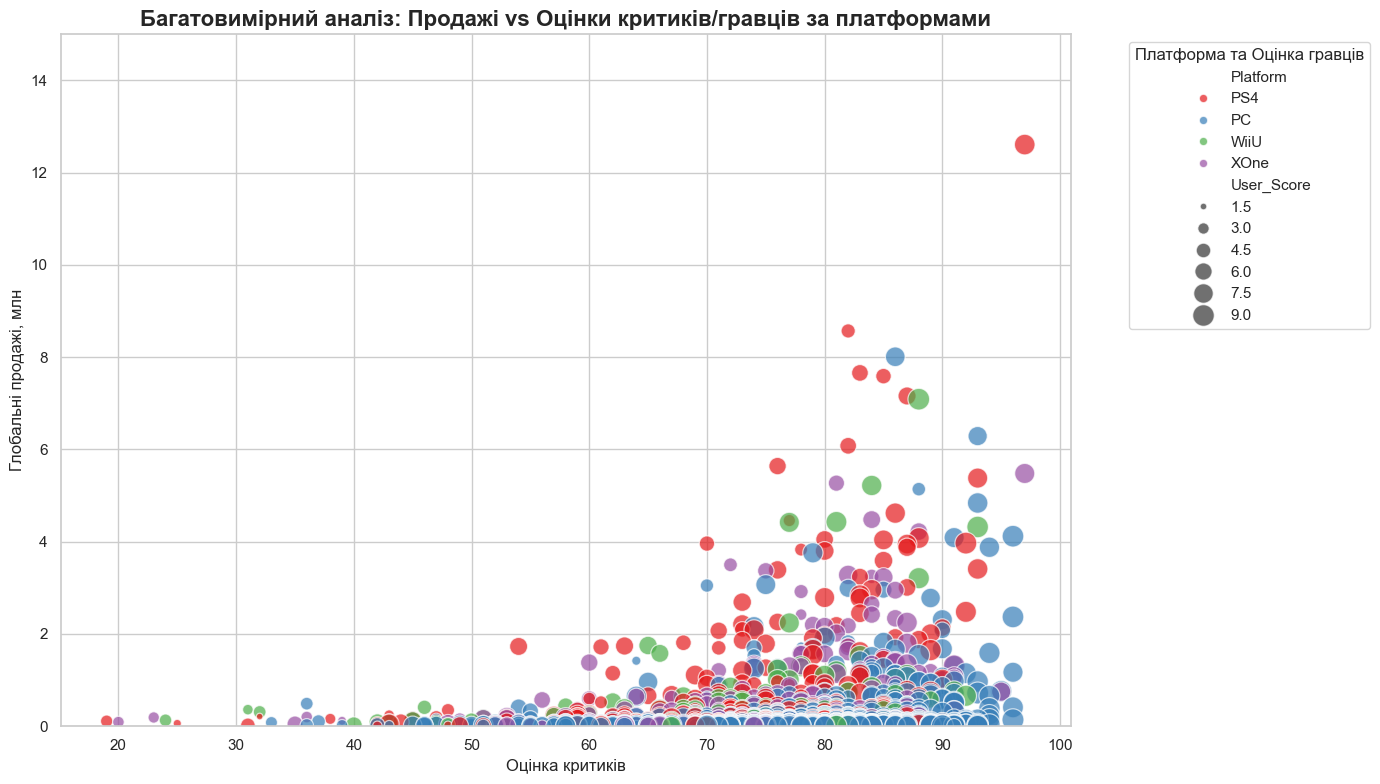

In [14]:
# Графік 3: Багатовимірна візуалізація
# Відображаємо 4 виміри на одному графіку: X, Y, Колір (Hue) та Розмір (Size)

plt.figure(figsize=(14, 8))

# Відфільтруємо лише 4 платформи 8-го покоління для наочності
platforms_to_show = ['PS4', 'XOne', 'PC', 'WiiU']
df_filtered = df[df['Platform'].isin(platforms_to_show)]

# Будуємо багатовимірний графік
sns.scatterplot(
    data=df_filtered,
    x='Critic_Score',
    y='Global_Sales',
    hue='Platform',       # 3-й вимір: колір означає платформу
    size='User_Score',    # 4-й вимір: розмір точки означає оцінку гравців
    sizes=(20, 250),      # Мінімальний та максимальний розміри точок
    alpha=0.7,            # Прозорість
    palette='Set1',       # Яскрава палітра кольорів
)

plt.title('Багатовимірний аналіз: Продажі vs Оцінки критиків/гравців за платформами', fontsize=16, fontweight='bold')
plt.xlabel('Оцінка критиків', fontsize=12)
plt.ylabel('Глобальні продажі, млн', fontsize=12)

# Обмежуємо вісь Y, щоб краще розгледіти основну масу ігор
plt.ylim(0, 15)

# Виносимо легенду за межі графіка, щоб вона не перекривала точки
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Платформа та Оцінка гравців")
plt.tight_layout()

plt.show()

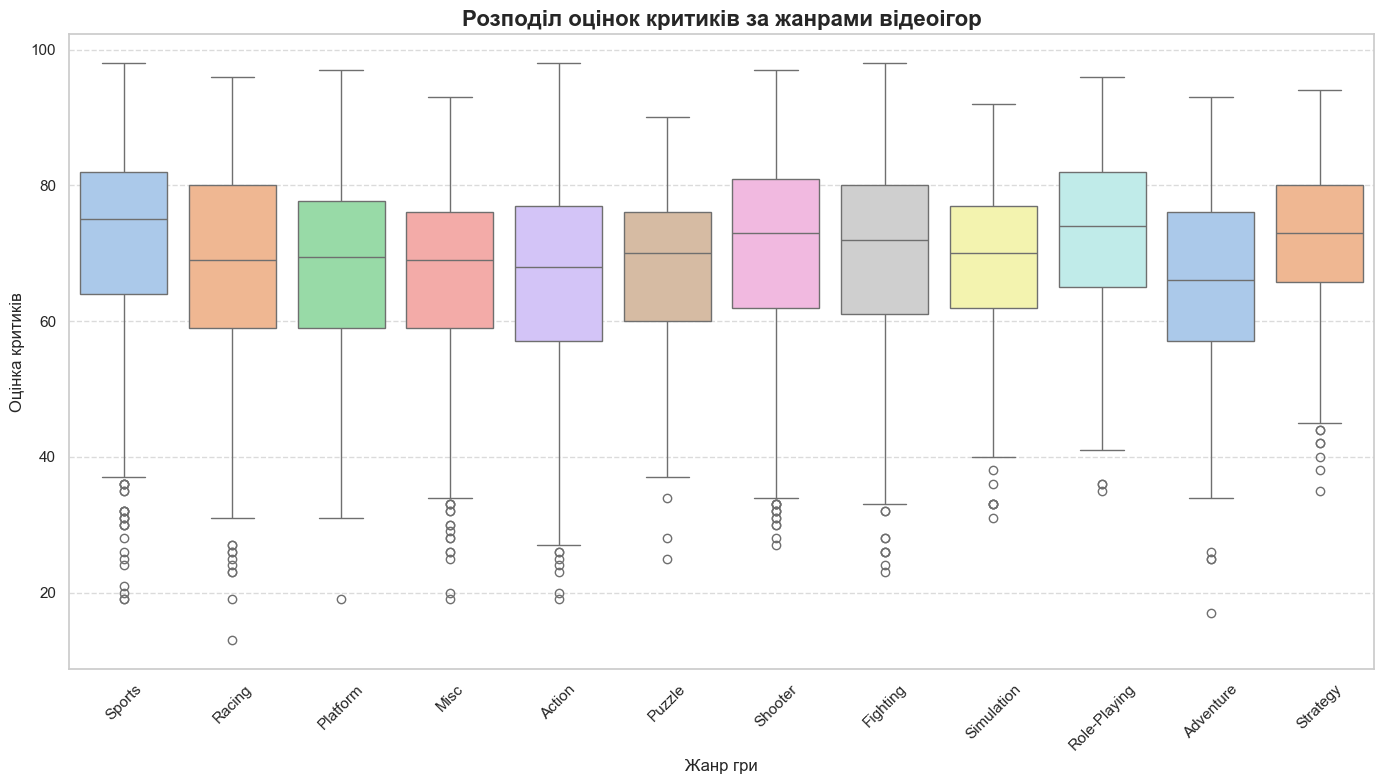

In [17]:
# Графік 4: Ящиковий графік (Boxplot)
# Показує корисну інформацію про розподіл оцінок всередині кожного жанру

plt.figure(figsize=(14, 8))

# Будуємо boxplot
sns.boxplot(
    data=df,
    x='Genre',
    y='Critic_Score',
    hue='Genre',         #  колір прив'язаний до жанру напряму
    palette='pastel',
    legend=False         # Вимикаємо легенду, бо жанри і так підписані знизу
)

plt.title('Розподіл оцінок критиків за жанрами відеоігор', fontsize=16, fontweight='bold')
plt.xlabel('Жанр гри', fontsize=12)
plt.ylabel('Оцінка критиків', fontsize=12)

# Повертаємо підписи осі X на 45 градусів, щоб вони не налізали один на одного
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

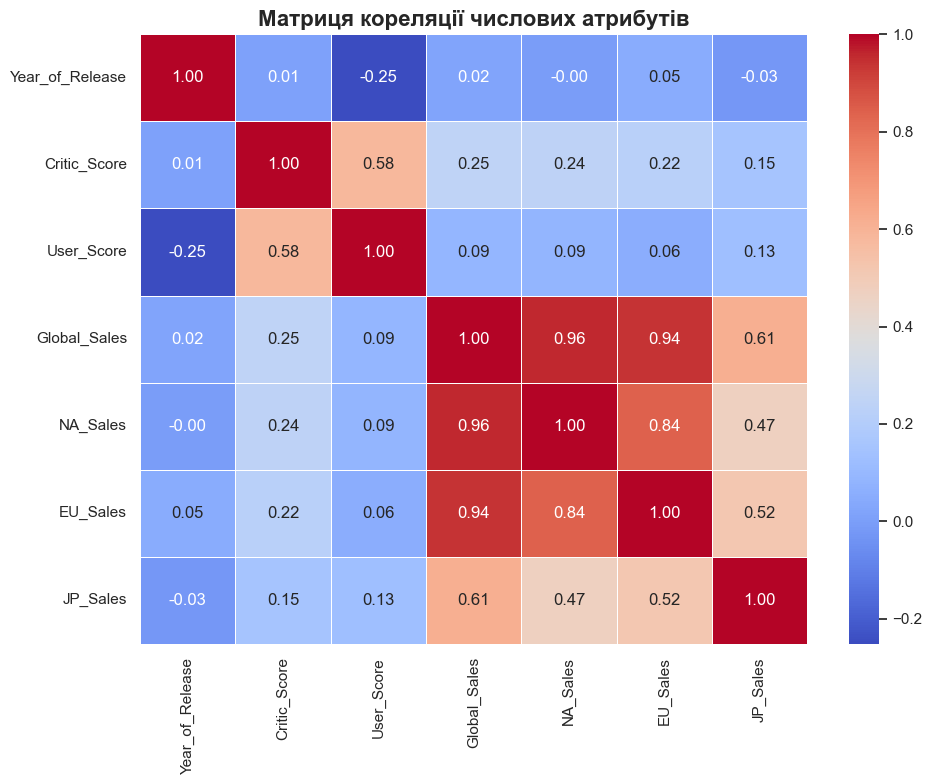

In [18]:
#  Графік 5: Теплова карта кореляції (Heatmap)
# Показує лінійну залежність між усіма числовими атрибутами датасету

plt.figure(figsize=(10, 8))

# Вибираємо лише числові колонки для побудови матриці кореляції
numeric_df = df[['Year_of_Release', 'Critic_Score', 'User_Score', 'Global_Sales', 'NA_Sales', 'EU_Sales', 'JP_Sales']]

# Обчислюємо кореляцію Пірсона та будуємо теплову карту
correlation_matrix = numeric_df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,          # Показувати цифри всередині квадратів
    cmap='coolwarm',     # Колірна палітра: від синього (мінус) до червоного (плюс)
    fmt='.2f',           # Округлення до двох знаків після коми
    linewidths=0.5
)

plt.title('Матриця кореляції числових атрибутів', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()